In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

TASK1

In [2]:
titanic = sns.load_dataset("titanic")

In [3]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
titanic.shape

(891, 15)

In [6]:
#2
titanic.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

In [7]:
numerical=titanic.select_dtypes(include="number").columns
numerical

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')

In [8]:
categorical = titanic.select_dtypes(include=["object", "string"]).columns
categorical

Index(['sex', 'embarked', 'who', 'embark_town', 'alive'], dtype='str')

In [9]:
#3
titanic.columns[titanic.isnull().any()]

Index(['age', 'embarked', 'deck', 'embark_town'], dtype='str')

In [10]:
missing = titanic.isnull().mean() * 100
missing

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [11]:
#4
titanic["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [12]:
survival_rate = titanic['survived'].mean() * 100
survival_rate

np.float64(38.38383838383838)

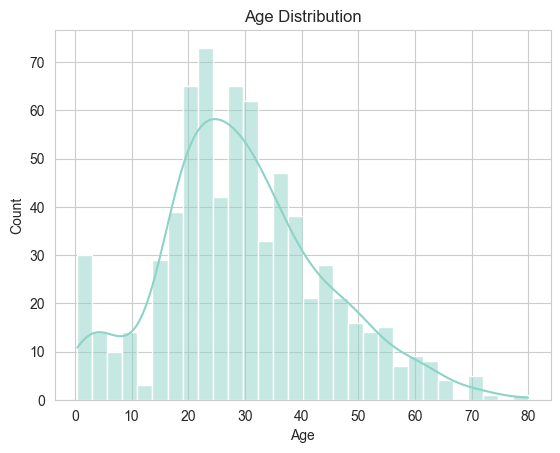

In [13]:
#5
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(titanic['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

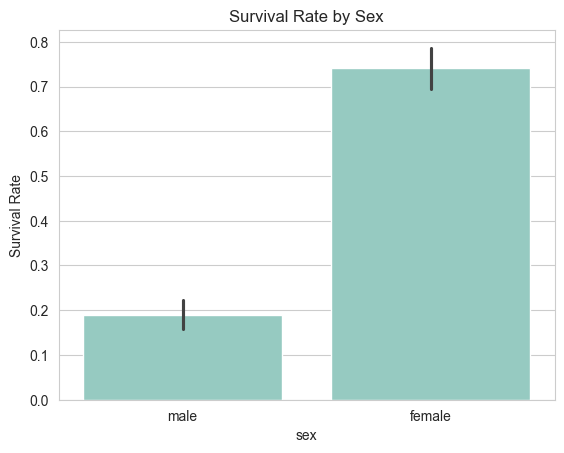

In [14]:
sns.barplot(x='sex', y='survived', data=titanic)
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

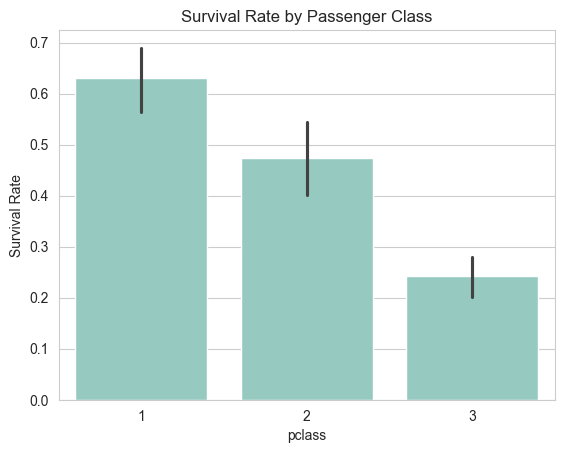

In [15]:
sns.barplot(x='pclass', y='survived', data=titanic)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

Most passengers are between 20–40 years old

Females had a much higher survival rate than males

1st class > 2nd class > 3rd class in survival probability
Higher socioeconomic status → better survival chances

TASK2

In [16]:
titanic["age"]=titanic["age"].fillna(titanic["age"].median())

In [17]:
titanic["embarked"]=titanic["embarked"].fillna(titanic["embarked"].mode()[0])

In [18]:
titanic=titanic.dropna(subset=['deck'])

In [19]:
#2
le = LabelEncoder()
titanic['sex'] = le.fit_transform(titanic['sex'])

In [20]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,0,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,0,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,1,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,0,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,0,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,0,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,1,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,0,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,0,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [21]:
titanic["embarked"].value_counts()

embarked
S    130
C     69
Q      4
Name: count, dtype: int64

In [22]:
titanic = pd.get_dummies(titanic, columns=["embarked"], drop_first=True)

In [23]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,deck,embark_town,alive,alone,embarked_Q,embarked_S
1,1,1,0,38.0,1,0,71.2833,First,woman,False,C,Cherbourg,yes,False,False,False
3,1,1,0,35.0,1,0,53.1000,First,woman,False,C,Southampton,yes,False,False,True
6,0,1,1,54.0,0,0,51.8625,First,man,True,E,Southampton,no,True,False,True
10,1,3,0,4.0,1,1,16.7000,Third,child,False,G,Southampton,yes,False,False,True
11,1,1,0,58.0,0,0,26.5500,First,woman,False,C,Southampton,yes,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,0,47.0,1,1,52.5542,First,woman,False,D,Southampton,yes,False,False,True
872,0,1,1,33.0,0,0,5.0000,First,man,True,B,Southampton,no,True,False,True
879,1,1,0,56.0,0,1,83.1583,First,woman,False,C,Cherbourg,yes,False,False,False
887,1,1,0,19.0,0,0,30.0000,First,woman,False,B,Southampton,yes,True,False,True


In [24]:
#3
titanic["family_size"] = titanic["sibsp"] + titanic["parch"] + 1

titanic["is_alone"] = (titanic["family_size"] == 1).astype(int)

In [25]:
titanic = titanic.drop(
    columns=["alive", "who", "adult_male", "embark_town", "class", "alone"],
    errors="ignore"
)

In [26]:
titanic = pd.get_dummies(titanic, drop_first=True)

In [27]:
print(titanic.head())
print(titanic.dtypes)

    survived  pclass  sex   age  sibsp  parch     fare  embarked_Q  \
1          1       1    0  38.0      1      0  71.2833       False   
3          1       1    0  35.0      1      0  53.1000       False   
6          0       1    1  54.0      0      0  51.8625       False   
10         1       3    0   4.0      1      1  16.7000       False   
11         1       1    0  58.0      0      0  26.5500       False   

    embarked_S  family_size  is_alone  deck_B  deck_C  deck_D  deck_E  deck_F  \
1        False            2         0   False    True   False   False   False   
3         True            2         0   False    True   False   False   False   
6         True            1         1   False   False   False    True   False   
10        True            3         0   False   False   False   False   False   
11        True            1         1   False    True   False   False   False   

    deck_G  
1    False  
3    False  
6    False  
10    True  
11   False  
survived      

In [28]:
titanic.select_dtypes(include=["number"]).shape[1] == titanic.shape[1]

False

TASK3

In [29]:
#1
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

titanic_scaled_std = titanic.copy()
titanic_scaled_mm = titanic.copy()

cols = ["age", "fare"]

titanic_scaled_std[cols] = scaler_std.fit_transform(titanic[cols])
titanic_scaled_mm[cols] = scaler_mm.fit_transform(titanic[cols])

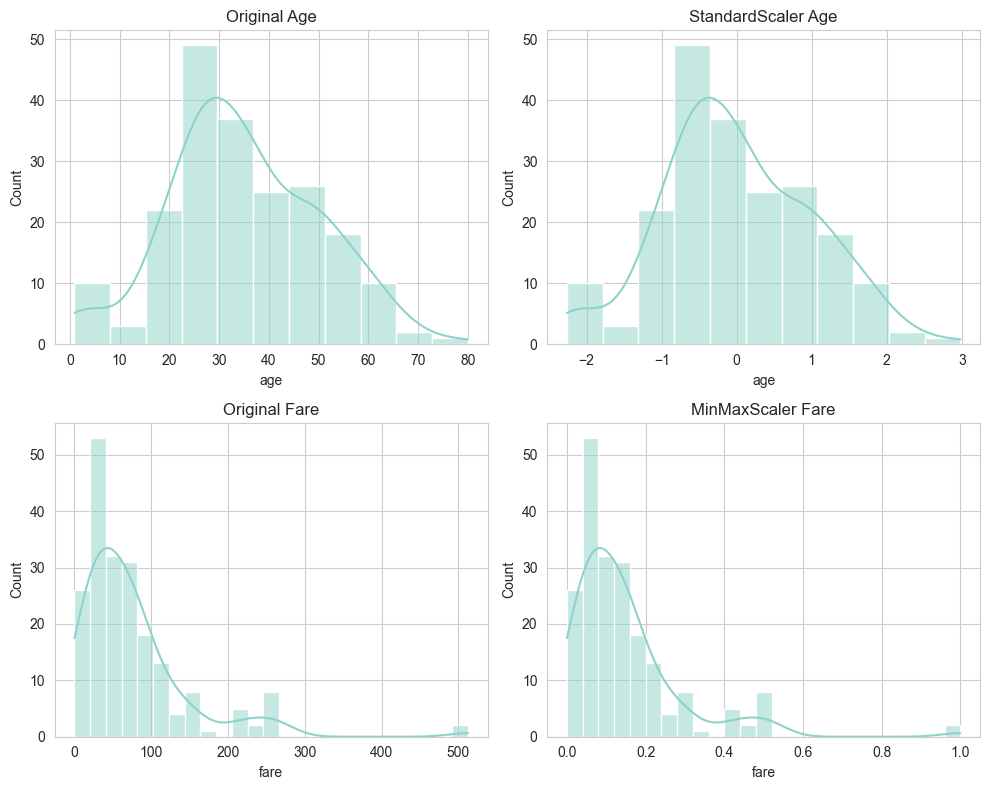

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))

sns.histplot(titanic["age"], ax=axes[0,0], kde=True).set_title("Original Age")
sns.histplot(titanic_scaled_std["age"], ax=axes[0,1], kde=True).set_title("StandardScaler Age")

sns.histplot(titanic["fare"], ax=axes[1,0], kde=True).set_title("Original Fare")
sns.histplot(titanic_scaled_mm["fare"], ax=axes[1,1], kde=True).set_title("MinMaxScaler Fare")

plt.tight_layout()
plt.show()

StandardScaler: Centers data around mean = 0, std = 1. Good for models assuming normal distribution.

MinMaxScaler: Scales values to [0,1]. Useful when preserving relative scale matters.

StandardScaler is more robust to outliers compared to MinMax.

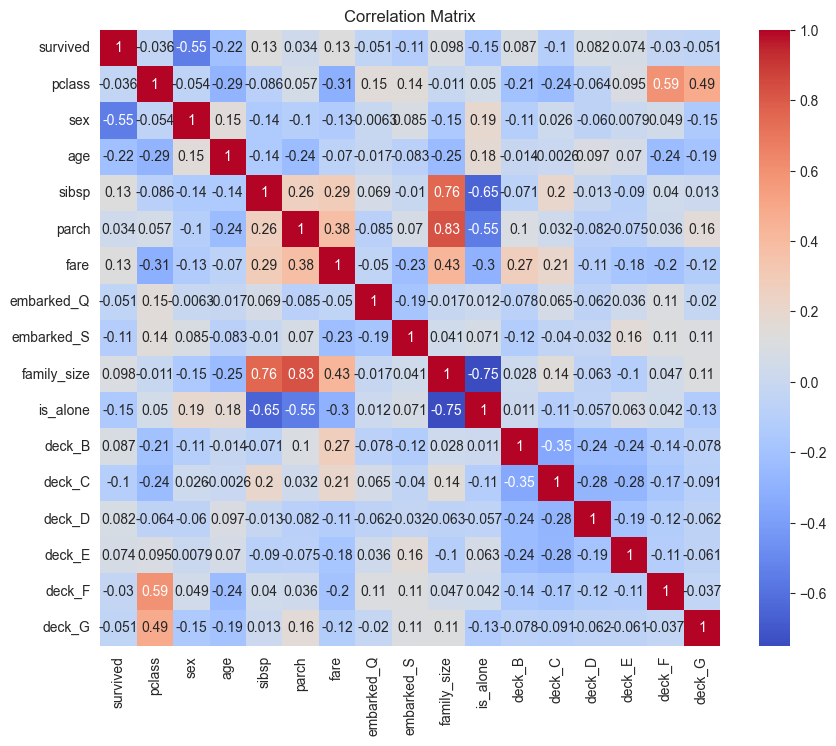

In [31]:
import seaborn as sns

corr = titanic.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [32]:
corr["survived"].sort_values(ascending=False)

survived       1.000000
sibsp          0.128490
fare           0.125201
family_size    0.097685
deck_B         0.087231
deck_D         0.082101
deck_E         0.073642
parch          0.034105
deck_F        -0.030353
pclass        -0.035825
deck_G        -0.051241
embarked_Q    -0.051241
deck_C        -0.104448
embarked_S    -0.111194
is_alone      -0.153602
age           -0.216370
sex           -0.545595
Name: survived, dtype: float64

Positive: sex (female), fare

Negative: pclass, is_alone

In [33]:
selected_features = corr["survived"][abs(corr["survived"]) >= 0.1]
selected_features

survived      1.000000
sex          -0.545595
age          -0.216370
sibsp         0.128490
fare          0.125201
embarked_S   -0.111194
is_alone     -0.153602
deck_C       -0.104448
Name: survived, dtype: float64

Selected features:
sex
pclass
fare
family_size
is_alone

Justification:
Features above threshold show meaningful linear relationship.
Borderline features (<0.1) contribute little predictive signal.

TASK4

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(titanic.drop("survived", axis=1))

In [35]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_

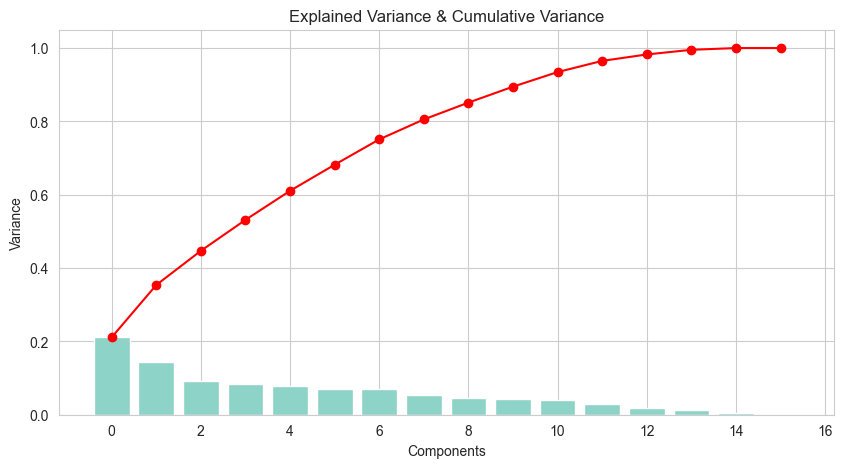

In [36]:
import numpy as np

plt.figure(figsize=(10,5))

# Bar plot
plt.bar(range(len(explained_variance)), explained_variance)

# Cumulative
plt.plot(np.cumsum(explained_variance), marker='o', color='red')

plt.title("Explained Variance & Cumulative Variance")
plt.xlabel("Components")
plt.ylabel("Variance")
plt.show()

In [37]:
np.argmax(np.cumsum(explained_variance) >= 0.8) + 1

np.int64(8)

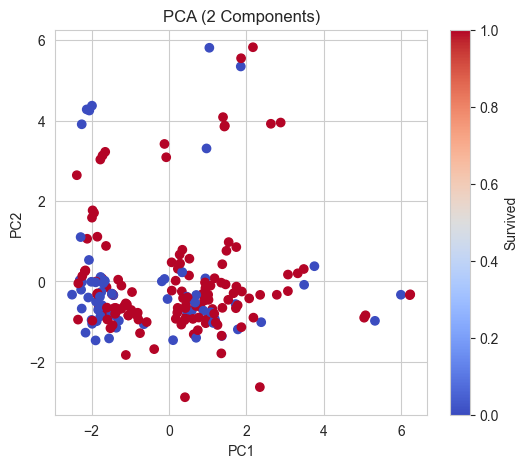

In [38]:
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=titanic["survived"], cmap="coolwarm")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2 Components)")
plt.colorbar(label="Survived")
plt.show()

PCA reduces dimensionality but does not strongly separate classes in this dataset.
Survivors and non-survivors still overlap significantly.

The dataset is not linearly separable in reduced space
Important information may be spread across multiple dimensions

PCA is useful for visualization.
But for modeling, original features are more informative.
Tree-based models (like Random Forest) work better without PCA here.